<class 'pandas.DataFrame'>
RangeIndex: 759 entries, 0 to 758
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SMILES    759 non-null    str    
 1   activity  759 non-null    float64
dtypes: float64(1), str(1)
memory usage: 12.0 KB


,SMILES,activity
0,OCC=C,5.0
1,CO/N=C(/C(=O)OC)\C1=C(COC2=C(C)C=CC=C2)C=CC=C1,94.0
2,COC(=O)NS(=O)(=O)C1=CC=C(N)C=C1,5.4
3,CCCCC(CC)C(O)=O,-8.2
4,COC(=O)C1=C(CC(C)C)C(C2=NCCS2)=C(N=C1C(F)F)C(F...,26.2


None

,SMILES,activity
count,759,759.000000
unique,759,NaN
top,OCC=C,NaN
freq,1,NaN
mean,NaN,40.691304
std,NaN,36.150662
min,NaN,-38.300000
25%,NaN,10.750000
50%,NaN,30.100000
75%,NaN,69.550000


Пропущенные значения в каждом столбце:
 SMILES      0
activity    0
dtype: int64
Количество дубликатов в данных: 0


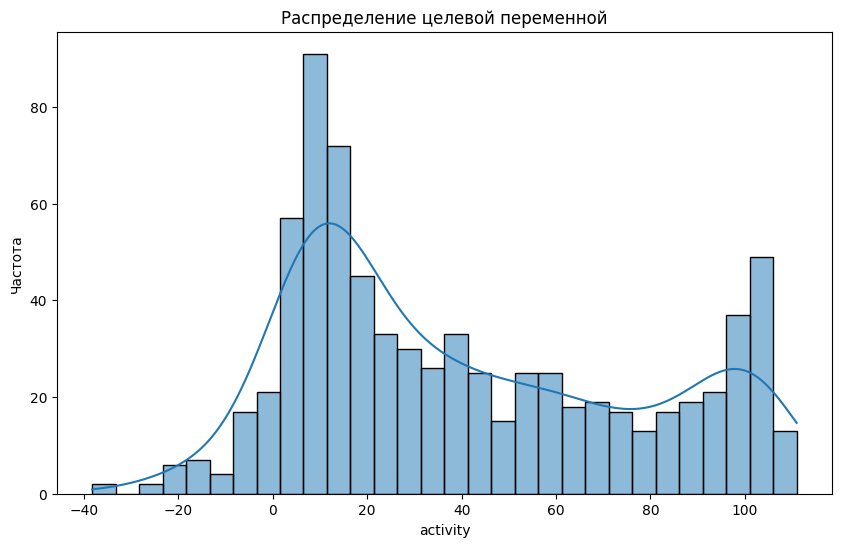

Проверка SMILES на валидность...
Все SMILES валидны.


[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerator
[16:17:21] DEPRECATION WARNING: please use MorganGenerat

Validation RMSE: 24.283
<class 'pandas.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  253 non-null    int64
 1   SMILES      253 non-null    str  
dtypes: int64(1), str(1)
memory usage: 4.1 KB


,Unnamed: 0,SMILES
0,0,CC(O)CCO
1,1,CCCCOCCOC(=O)COC1=C(Cl)C=C(Cl)C=C1
2,2,CO/N=C(/C1=NOCCO1)\C2=C(OC3=NC=NC(OC4=CC=CC=C4...
3,3,C=CC(=O)NCNC(=O)C=C
4,4,CC1=CC(=CC=C1)[N+]([O-])=O


None

,Unnamed: 0,SMILES
count,253.000000,253
unique,NaN,253
top,NaN,CC(O)CCO
freq,NaN,1
mean,126.000000,NaN
std,73.179004,NaN
min,0.000000,NaN
25%,63.000000,NaN
50%,126.000000,NaN
75%,189.000000,NaN


Invalid SMILES: []


[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerator
[16:17:23] DEPRECATION WARNING: please use MorganGenerat

Предсказания сохранены в submission.csv


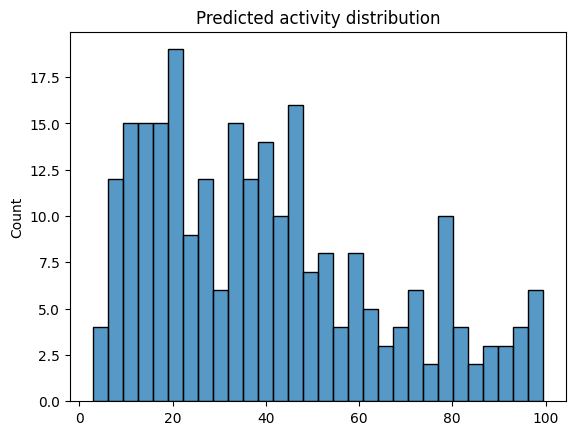

In [ ]:

import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы


train = pd.read_csv('/Users/konstantingeneralov/IDE/Data/train.csv', sep=',') #чтение данных из файла
train_df = train.copy() #копирование данных в новый датафрейм
display(train_df.head(), train_df.info(), train_df.describe(include='all')) #вывод первых 5 строк, информации о датафрейме и статистического описания

#произведем анализ данных
#проверим наличие пропущенных значений
missing_values = train_df.isnull().sum()
print("Пропущенные значения в каждом столбце:\n", missing_values)
#проверим наличие дубликатов
duplicate_rows = train_df.duplicated().sum()
print("Количество дубликатов в данных:", duplicate_rows)
#Пропущенные значения и дубликаты отсутствуют.

#распределение целевой переменной
plt.figure(figsize=(10, 6))
sns.histplot(train_df['activity'], bins=30, kde=True)
plt.title('Распределение целевой переменной')
plt.xlabel('activity')
plt.ylabel('Частота')
plt.show()
#Распределение не нормальное с асиметрией. Такое распределение вероятно обусловлено несколькими химическими классами и механизмами действия.


from rdkit import Chem

def check_smiles(smiles):
    valid = []
    invalid_idx = []
    for i, s in enumerate(smiles):
        if Chem.MolFromSmiles(s) is None:
            invalid_idx.append(i)
        else:
            valid.append(s)
    return valid, invalid_idx
print("Проверка SMILES на валидность...")
valid_smiles, invalid_indices = check_smiles(train_df.SMILES)
if invalid_indices:
    print(f"Найдены невалидные SMILES на индексах: {invalid_indices}")
else:
    print("Все SMILES валидны.")
 

from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors


def smiles_to_fp(smiles):
    '''Convert SMILES to Morgan fingerprints'''
    return np.array([AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=1024) for s in smiles])

X_train = smiles_to_fp(train_df.SMILES)

# Разделим данные на обучающую и валидационную выборки
X = train_df.SMILES
y = train_df.activity
X_train_smiles, X_val_smiles, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразуем SMILES в числовые признаки (например, с помощью Morgan fingerprints)
X_train = smiles_to_fp(X_train_smiles)
X_val = smiles_to_fp(X_val_smiles)

# Обучим модель
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

y_val_pred = model.predict(X_val)

mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
print(f'Validation RMSE: {rmse:.3f}')

# Обучил модель и провалидировал ее. Метрика: RMSE = 24.283


# протестируем модель на тестовом датасете
test = pd.read_csv('/Users/konstantingeneralov/IDE/Data/test_only_smiles.csv', sep=',') #чтение данных из файла
test_df = test.copy() #копирование данных в новый датафрейм
display(test_df.head(), test_df.info(), test_df.describe(include='all')) #вывод первых 5 строк, информации о датафрейме и статистического описания

# проверка SMILES на валидность
from rdkit import Chem

def check_smiles(smiles):
    invalid = []
    for i, s in enumerate(smiles):
        if Chem.MolFromSmiles(s) is None:
            invalid.append(i)
    return invalid

invalid_idx = check_smiles(test_df.SMILES)
print("Invalid SMILES:", invalid_idx)

# генерация признаков для тестового датасета
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles):
    fps = []
    for s in smiles:
        mol = Chem.MolFromSmiles(s)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
        fps.append(fp)
    return np.array(fps)

X_test = smiles_to_fp(test_df.SMILES)

# предсказание на тестовом датасете
y_test_pred = model.predict(X_test)

#Модель была применена к тестовому набору данных для генерации предсказаний биологической активности соединений.

# сохранение предсказаний в файл
if 'id' in test_df.columns:
    submission = pd.DataFrame({
        'id': test_df['id'],
        'activity': y_test_pred
    })
else:
    submission = pd.DataFrame({
        'id': test_df.index,
        'activity': y_test_pred
    })
submission.to_csv('/Users/konstantingeneralov/IDE/Data/submission.csv', index=False)
print("Предсказания сохранены в submission.csv")    

#проверим распределение предсказанных значений
sns.histplot(y_test_pred, bins=30)
plt.title("Predicted activity distribution")
plt.show()

# Распределение предсказанной активности на тестовом наборе имеет форму, схожую с распределением обучающей выборки, 
# что свидетельствует об отсутствии существенного distribution shift.
# Модель предсказывает широкий диапазон значений активности, включая высокоактивные соединения, 
# что указывает на способность различать химические структуры по биологической активности.

